## PHASE 2: DATA CLEANING
### Goal: Fix data issues and prepare clean data for analysis

### What we're fixing:
#### 1. Convert Date from text to datetime
#### 2. Sort data chronologically
#### 3. Handle any data quality issues
#### 4. Save cleaned data for next phases

In [1]:
import os
# Ensure CWD is always the project root regardless of how the notebook is launched
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f'Working directory: {os.getcwd()}')


Working directory: /Users/paarth_ganesh/Documents/ML-Projects/sales-forecasting-dashboard


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("="*70)
print("PHASE 2: DATA CLEANING")
print("="*70)
print("\nLibraries imported!")

PHASE 2: DATA CLEANING

Libraries imported!


In [3]:
"""
STEP 1: Load the raw data
We always load from the 'raw' folder (original, unchanged data)
"""

# Load data
df = pd.read_csv('data/raw/sales_data.csv')

print("="*70)
print("RAW DATA LOADED")
print("="*70)
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())

print("\n" + "="*70)
print("CURRENT DATA TYPES:")
print("="*70)
print(df.dtypes)

RAW DATA LOADED
Shape: (17520, 4)

First 5 rows:
         Date      Product Region    Sales
0  2021-01-01  Electronics  North  1742.99
1  2021-01-01  Electronics  South  1400.06
2  2021-01-01  Electronics   East  1568.32
3  2021-01-01  Electronics   West  1769.42
4  2021-01-01     Clothing  North   877.64

CURRENT DATA TYPES:
Date        object
Product     object
Region      object
Sales      float64
dtype: object


In [4]:
"""
STEP 2: Convert Date to datetime format
This is THE MOST IMPORTANT step for time series!
"""

print("="*70)
print("FIXING DATE COLUMN")
print("="*70)

# Before conversion
print("Before conversion:")
print(f"  Data type: {df['Date'].dtype}")
print(f"  Sample value: {df['Date'].iloc[0]}")
print(f"  Python type: {type(df['Date'].iloc[0])}")

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'])

# After conversion
print("\nAfter conversion:")
print(f"  Data type: {df['Date'].dtype}")
print(f"  Sample value: {df['Date'].iloc[0]}")
print(f"  Python type: {type(df['Date'].iloc[0])}")

print("\nSUCCESS! Date is now datetime64[ns]")

FIXING DATE COLUMN
Before conversion:
  Data type: object
  Sample value: 2021-01-01
  Python type: <class 'str'>

After conversion:
  Data type: datetime64[ns]
  Sample value: 2021-01-01 00:00:00
  Python type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>

SUCCESS! Date is now datetime64[ns]


In [5]:
"""
STEP 3: Sort data chronologically
For time series, ORDER MATTERS!
"""

print("="*70)
print("SORTING DATA BY DATE")
print("="*70)

# Check current order
print("First 10 rows BEFORE sorting:")
print(df[['Date', 'Sales']].head(10))

# Sort by date
df = df.sort_values('Date').reset_index(drop=True)

print("\nFirst 10 rows AFTER sorting:")
print(df[['Date', 'Sales']].head(10))

# Verify date range
print("\n" + "="*70)
print("DATE RANGE:")
print("="*70)
print(f"Earliest date: {df['Date'].min()}")
print(f"Latest date:   {df['Date'].max()}")
print(f"Total days:    {(df['Date'].max() - df['Date'].min()).days + 1}")

SORTING DATA BY DATE
First 10 rows BEFORE sorting:
        Date    Sales
0 2021-01-01  1742.99
1 2021-01-01  1400.06
2 2021-01-01  1568.32
3 2021-01-01  1769.42
4 2021-01-01   877.64
5 2021-01-01   728.76
6 2021-01-01   910.54
7 2021-01-01   922.02
8 2021-01-01   819.65
9 2021-01-01   737.07

First 10 rows AFTER sorting:
        Date    Sales
0 2021-01-01  1742.99
1 2021-01-01  1030.22
2 2021-01-01   866.71
3 2021-01-01   792.90
4 2021-01-01  1135.93
5 2021-01-01   732.19
6 2021-01-01   737.07
7 2021-01-01   819.65
8 2021-01-01   790.62
9 2021-01-01   910.54

DATE RANGE:
Earliest date: 2021-01-01 00:00:00
Latest date:   2023-12-31 00:00:00
Total days:    1095


In [6]:
"""
STEP 4: Check for duplicate dates
Each date should appear only once (for daily data)
"""

print("="*70)
print("🔍 CHECKING FOR DUPLICATES")
print("="*70)

# Count duplicates
duplicates = df.duplicated(subset=['Date']).sum()

print(f"Number of duplicate dates: {duplicates}")

if duplicates > 0:
    print("\nWARNING: Duplicate dates found!")
    print("Duplicate dates:")
    duplicate_dates = df[df.duplicated(subset=['Date'], keep=False)].sort_values('Date')
    print(duplicate_dates[['Date', 'Product', 'Region', 'Sales']])
    
    print("\nWe should handle these - options:")
    print("  1. Keep first occurrence")
    print("  2. Keep last occurrence")
    print("  3. Average the values")
    print("  4. Sum the values (if it makes sense)")
else:
    print("No duplicate dates found - data is clean!")

🔍 CHECKING FOR DUPLICATES
Number of duplicate dates: 16425

Duplicate dates:
            Date      Product Region    Sales
0     2021-01-01  Electronics  North  1742.99
15    2021-01-01     Clothing   West   922.02
14    2021-01-01  Electronics  South  1400.06
13    2021-01-01  Electronics   East  1568.32
12    2021-01-01  Electronics   West  1769.42
...          ...          ...    ...      ...
17505 2023-12-31    Furniture  North  1990.32
17504 2023-12-31    Furniture  South  1696.27
17518 2023-12-31     Clothing   East  1623.65
17510 2023-12-31     Clothing   West  1856.91
17519 2023-12-31    Furniture   West  1927.17

[17520 rows x 4 columns]

We should handle these - options:
  1. Keep first occurrence
  2. Keep last occurrence
  3. Average the values
  4. Sum the values (if it makes sense)


In [7]:
"""
STEP 5: Final data quality checks
"""

print("="*70)
print("DATA QUALITY VERIFICATION")
print("="*70)

# 1. Check date continuity (any missing dates?)
date_range = pd.date_range(start=df['Date'].min(), end=df['Date'].max(), freq='D')
missing_dates = date_range.difference(df['Date'])

print(f"\nDATE CONTINUITY CHECK:")
print(f"   Expected dates: {len(date_range)}")
print(f"   Actual dates:   {df['Date'].nunique()}")
print(f"   Missing dates:  {len(missing_dates)}")

if len(missing_dates) > 0:
    print("\nMissing dates found:")
    print(f"{missing_dates[:10]}")  # Show first 10
else:
    print("No missing dates - complete timeline!")

# 2. Check for negative sales
negative_sales = (df['Sales'] < 0).sum()
print(f"\nSALES VALUES CHECK:")
print(f"   Negative sales count: {negative_sales}")
if negative_sales > 0:
    print("Warning: Negative sales found!")
    print(df[df['Sales'] < 0])
else:
    print("All sales values are positive!")

# 3. Check for extreme outliers
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Sales'] < Q1 - 1.5*IQR) | (df['Sales'] > Q3 + 1.5*IQR)]

print(f"\nOUTLIER CHECK:")
print(f"   Lower bound: ${Q1 - 1.5*IQR:,.2f}")
print(f"   Upper bound: ${Q3 + 1.5*IQR:,.2f}")
print(f"   Outliers found: {len(outliers)}")
if len(outliers) > 0:
    print(f"Outlier percentage: {len(outliers)/len(df)*100:.2f}%")
    print("\nSample outliers:")
    print(outliers[['Date', 'Product', 'Sales']].head())
else:
    print("No extreme outliers detected!")

# 4. Missing values
print(f"\nMISSING VALUES:")
missing = df.isnull().sum()
print(missing)
if missing.sum() == 0:
    print("No missing values!")

DATA QUALITY VERIFICATION

DATE CONTINUITY CHECK:
   Expected dates: 1095
   Actual dates:   1095
   Missing dates:  0
No missing dates - complete timeline!

SALES VALUES CHECK:
   Negative sales count: 0
All sales values are positive!

OUTLIER CHECK:
   Lower bound: $536.96
   Upper bound: $2,326.48
   Outliers found: 78
Outlier percentage: 0.45%

Sample outliers:
            Date      Product    Sales
6856  2022-03-05  Electronics  2412.82
11231 2022-12-03  Electronics  2350.78
11470 2022-12-18  Electronics  2432.85
11567 2022-12-24  Electronics  2370.12
11806 2023-01-08  Electronics  2517.66

MISSING VALUES:
Date       0
Product    0
Region     0
Sales      0
dtype: int64
No missing values!


VISUALIZING CLEANED DATA


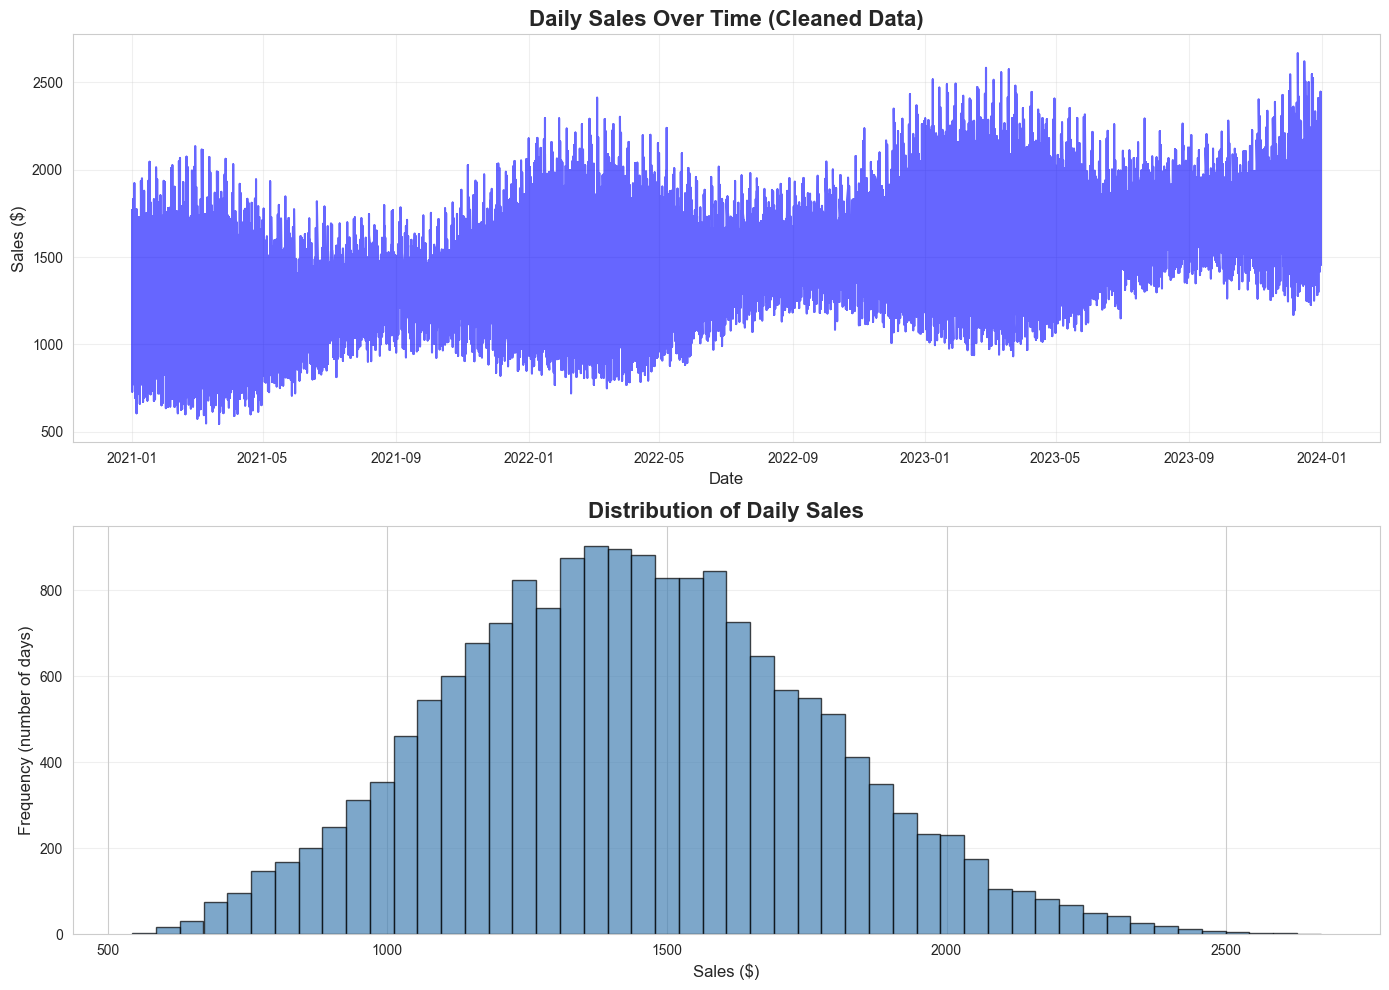


Visualizations created!

INSIGHTS:
   • Top plot shows trend over time
   • Bottom plot shows distribution (most common sales ranges)


In [8]:
"""
STEP 6: Visualize the cleaned data
"""

print("="*70)
print("VISUALIZING CLEANED DATA")
print("="*70)

# Plot 1: Sales over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Daily sales
axes[0].plot(df['Date'], df['Sales'], alpha=0.6, color='blue')
axes[0].set_title('Daily Sales Over Time (Cleaned Data)', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Sales ($)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Sales distribution (histogram)
axes[1].hist(df['Sales'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Daily Sales', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Sales ($)', fontsize=12)
axes[1].set_ylabel('Frequency (number of days)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nVisualizations created!")
print("\nINSIGHTS:")
print("   • Top plot shows trend over time")
print("   • Bottom plot shows distribution (most common sales ranges)")

In [9]:
"""
STEP 7: Save the cleaned data
We save it to the 'processed' folder, never overwrite raw data!
"""

print("="*70)
print("SAVING CLEANED DATA")
print("="*70)

# Save to processed folder
output_path = 'data/processed/sales_data_clean.csv'
df.to_csv(output_path, index=False)

print(f"Cleaned data saved to: {output_path}")
print(f"   Rows: {len(df)}")
print(f"   Columns: {len(df.columns)}")

# Verify it saved correctly
verify_df = pd.read_csv(output_path)
print(f"\nVerification: File loaded successfully")
print(f"   Shape: {verify_df.shape}")

SAVING CLEANED DATA
Cleaned data saved to: data/processed/sales_data_clean.csv
   Rows: 17520
   Columns: 4

Verification: File loaded successfully
   Shape: (17520, 4)


In [10]:
"""
PHASE 2 COMPLETE: Cleaning Summary
"""

print("="*70)
print("PHASE 2: DATA CLEANING - SUMMARY REPORT")
print("="*70)

print("\nTASKS COMPLETED:")
print("   1. ✓ Loaded raw data from data/raw/")
print("   2. ✓ Converted Date from 'object' to 'datetime64'")
print("   3. ✓ Sorted data chronologically")
print("   4. ✓ Checked for duplicates")
print("   5. ✓ Verified date continuity")
print("   6. ✓ Checked for negative sales")
print("   7. ✓ Detected outliers (if any)")
print("   8. ✓ Visualized cleaned data")
print("   9. ✓ Saved to data/processed/")

print("\nCLEANED DATASET STATS:")
print(f"   • Total records: {len(df):,}")
print(f"   • Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"   • Number of days: {(df['Date'].max() - df['Date'].min()).days + 1}")
print(f"   • Average daily sales: ${df['Sales'].mean():,.2f}")
print(f"   • Total sales: ${df['Sales'].sum():,.2f}")

print("\nNEXT STEPS (Phase 3 - Feature Engineering):")
print("   1. Extract time features (Year, Month, Day, DayOfWeek, Quarter …)")
print("   2. Create trend feature (Days_Since_Start)")
print("   3. Create binary flags (Is_Weekend, Is_Q4, Is_December …)")
print("   4. Create per-product-region lag features (Lag_1, Lag_7, Lag_14, Lag_30)")
print("   5. Create rolling statistics (MA_7, MA_14, MA_30, Std_7)")
print("   6. One-hot encode Product and Region → 29 total model features")

print("\n" + "="*70)
print("\nPHASE 2 COMPLETE! Data is now clean and ready.")
print("="*70)


PHASE 2: DATA CLEANING - SUMMARY REPORT

TASKS COMPLETED:
   1. ✓ Loaded raw data from data/raw/
   2. ✓ Converted Date from 'object' to 'datetime64'
   3. ✓ Sorted data chronologically
   4. ✓ Checked for duplicates
   5. ✓ Verified date continuity
   6. ✓ Checked for negative sales
   7. ✓ Detected outliers (if any)
   8. ✓ Visualized cleaned data
   9. ✓ Saved to data/processed/

CLEANED DATASET STATS:
   • Total records: 17,520
   • Date range: 2021-01-01 to 2023-12-31
   • Number of days: 1095
   • Average daily sales: $1,438.26
   • Total sales: $25,198,344.29

NEXT STEPS (Phase 3 - Feature Engineering):
   1. Extract time features (year, month, day of week)
   2. Create lag features (yesterday's sales)
   3. Create rolling averages (7-day, 30-day)
   4. Create seasonal indicators
   5. Prepare features for modeling


PHASE 2 COMPLETE! Data is now clean and ready.
